## Estadísticas de la distribución de materia: Power Spectrum y Halo Mass Function

Una vez construidos los campos de densidad y estudiadas sus propiedades espaciales, podemos cuantificar la distribución de materia usando estadísticas que resumen diferentes aspectos de la estructura a gran escala.

En esta sección calcularemos:

1. El **Power Spectrum de materia** a $z=0$.
2. La **Halo Mass Function (HMF)** a $z=0$ y $z=0.5$.

Estas dos estadísticas contienen información complementaria:

- el Power Spectrum describe cómo se distribuyen las fluctuaciones de densidad en función de la escala;
- la HMF describe la abundancia de halos en función de su masa.

---

### 1. Power Spectrum de materia a $z=0$

El campo de contraste de densidad se define como

$$
\delta(\mathbf{x})
=
\frac{\rho(\mathbf{x})-\bar{\rho}}
{\bar{\rho}}.
$$

Para estudiar las fluctuaciones en diferentes escalas espaciales transformamos este campo al espacio de Fourier,

$$
\delta(\mathbf{k})
=
\int
\delta(\mathbf{x})
e^{-i\mathbf{k}\cdot\mathbf{x}}
\,d^3x.
$$

El Power Spectrum se define mediante

$$
\langle
\delta(\mathbf{k})
\delta^*(\mathbf{k}')
\rangle
=
(2\pi)^3
\delta_D(\mathbf{k}-\mathbf{k}')
P(k),
$$

donde $P(k)$ mide la amplitud de las fluctuaciones de densidad como función del número de onda $k$.

El número de onda está relacionado con la escala espacial aproximadamente mediante

$$
\lambda = \frac{2\pi}{k}.
$$

Por lo tanto:

- valores pequeños de $k$ corresponden a escalas espaciales grandes;
- valores grandes de $k$ corresponden a escalas espaciales pequeñas.

Para una caja periódica de tamaño $L_{\rm box}$, el modo fundamental de Fourier es

$$
k_{\rm f}
=
\frac{2\pi}{L_{\rm box}},
$$

mientras que el máximo número de onda que puede representarse en una malla con $N_{\rm grid}$ celdas está relacionado con la frecuencia de Nyquist,

$$
k_{\rm Ny}
=
\frac{\pi N_{\rm grid}}{L_{\rm box}}.
$$

Calcularemos el Power Spectrum del snapshot a $z=0$ utilizando **Pylians**, a partir de la distribución de partículas de L-PICOLA.

El objetivo será observar cómo la simulación reproduce la distribución de potencia desde las escalas lineales hasta escalas progresivamente más no lineales.

---

### 2. Identificación de halos

Además de estudiar directamente el campo de materia, podemos identificar estructuras gravitacionalmente colapsadas mediante un algoritmo **Friends-of-Friends (FoF)**.

El método FoF conecta partículas cuya separación es menor que una determinada longitud de enlace,

$$
l_{\rm link}
=
b\,\bar{l},
$$

donde $\bar{l}$ es la separación media entre partículas y normalmente se utiliza

$$
b = 0.2.
$$

Las partículas conectadas entre sí forman un grupo que identificaremos como un halo.

Si todas las partículas de la simulación tienen la misma masa $m_{\rm p}$, la masa de un halo FoF puede obtenerse simplemente como

$$
M_{\rm halo}
=
N_{\rm p,halo}\,m_{\rm p},
$$

donde $N_{\rm p,halo}$ es el número de partículas pertenecientes al halo.

Para evitar halos muy pobremente resueltos, utilizaremos un número mínimo de partículas por grupo, por ejemplo

$$
N_{\rm p,halo}\geq 20.
$$

Esto determina una masa mínima nominal,

$$
M_{\rm min}
=
20\,m_{\rm p}.
$$

---

### 3. Halo Mass Function

Una vez identificados los halos podemos calcular su abundancia en distintos intervalos de masa.

La **Halo Mass Function** puede expresarse como

$$
\frac{dn}{d\ln M},
$$

que representa el número de halos por unidad de volumen y por intervalo logarítmico de masa.

Numéricamente, para un bin de masa $i$,

$$
\frac{dn}{d\ln M}
\simeq
\frac{N_i}
{V\,\Delta\ln M_i},
$$

donde

- $N_i$ es el número de halos en el bin;
- $V=L_{\rm box}^3$ es el volumen de la simulación;
- $\Delta\ln M_i$ es el ancho logarítmico del bin.

Calcularemos la HMF para los snapshots a

$$
z=0
\qquad\text{y}\qquad
z=0.5,
$$

utilizando los mismos bins de masa para poder comparar directamente la evolución de la abundancia de halos.

En general, a redshifts más bajos ha habido más tiempo para el crecimiento gravitacional, por lo que esperamos encontrar una mayor abundancia de halos masivos a $z=0$ que a $z=0.5$.

---

### 4. Comparación con una predicción teórica

Finalmente compararemos la HMF medida en las simulaciones de L-PICOLA con una predicción teórica calculada mediante **Colossus**.

Como los halos de la simulación fueron identificados mediante Friends-of-Friends, utilizaremos una función de masa calibrada para halos FoF, como el modelo de **Watson et al. (2013)**.

Esto permite comparar

$$
\left(\frac{dn}{d\ln M}\right)_{\rm L-PICOLA}
$$

con

$$
\left(\frac{dn}{d\ln M}\right)_{\rm theory}.
$$

Un buen acuerdo en la Halo Mass Function significa que la simulación reproduce adecuadamente la **abundancia estadística de halos**.

Sin embargo, esto no implica necesariamente que L-PICOLA reproduzca con la misma precisión las propiedades internas o la correspondencia halo-a-halo con una simulación N-body de alta precisión.

En particular, los halos formados por un número pequeño de partículas son más sensibles a la resolución de la simulación. Por esta razón, es útil interpretar los resultados teniendo en cuenta el número de partículas que resuelve cada halo.

**Tutorial basado en tutorial de Pylians**: https://quijote-simulations.readthedocs.io/en/latest/tutorials.html

In [88]:
import numpy as np
import readgadget
import readfof
import MAS_library as MASL
import Pk_library as PKL
import redshift_space_library as RSL

# Power Spectrum

We start by computing the matter power spectrum of a snapshot

In [89]:
snapshot = '../../codes/l-picola/snapshots/test_z0p000'
grid     = 512    #the density field will have grid^3 voxels
MAS      = 'CIC'  #Mass-assignment scheme:'NGP', 'CIC', 'TSC', 'PCS'
verbose  = True   #whether to print information about the progress
ptype    = [1]    #[1](CDM
axis = 0    #axis along which redshift-space distortions have been placed. In real-space this parameter doesnt matter
threads = 1 #number of openmp threads to compute the power spectrum

In [90]:
# read the redshift, boxsize, cosmology...etc in the header
header   = readgadget.header(snapshot)
BoxSize  = header.boxsize  #Mpc/h
Nall     = header.nall         #Total number of particles
Masses   = header.massarr*1e10 #Masses of the particles in Msun/h
Omega_m  = header.omega_m      #value of Omega_m
Omega_l  = header.omega_l      #value of Omega_l
h        = header.hubble       #value of h
redshift = header.redshift     #redshift of the snapshot
Hubble   = 100.0*np.sqrt(Omega_m*(1.0+redshift)**3+Omega_l)#Value of H(z) in km/s/(Mpc/h)

# read positions of the dark matter particles
pos = readgadget.read_block(snapshot, "POS ", [1]) #positions in Mpc/h

Getting the contrast density field

In [91]:
delta = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(pos, delta, BoxSize, MAS, verbose=verbose)
delta /= np.mean(delta, dtype=np.float64);  delta -= 1.0

# print some information
print('%.3f < delta < %.3f'%(np.min(delta), np.max(delta)))
print('< delta > = %.3f'%np.mean(delta))


Using CIC mass assignment scheme
Time taken = 0.341 seconds

-1.000 < delta < 1421.675
< delta > = -0.000


Computing the power spectrum

In [92]:
Pk = PKL.Pk(delta, BoxSize, axis, MAS, threads, verbose)
k       = Pk.k3D
Pk0     = Pk.Pk[:,0]


Computing power spectrum of the field...
Time to complete loop = 3.08
Time taken = 4.58 seconds


Loading the theoritical power spectrum

In [93]:
pk_theo= '/home/greco/Puebla_school/cosmobase/codes/l-picola/files/input_spectrum.dat'
k_theo = np.loadtxt(pk_theo)[:,0]
pk_theo = np.loadtxt(pk_theo)[:,1]

In [94]:
pk_theo2_path = '/home/greco/Puebla_school/cosmobase/codes/l-picola/files/sfdm02_pk.dat'
k_theo2 = np.loadtxt(pk_theo2_path)[:,0]
pk_theo2 = np.loadtxt(pk_theo2_path)[:,1]

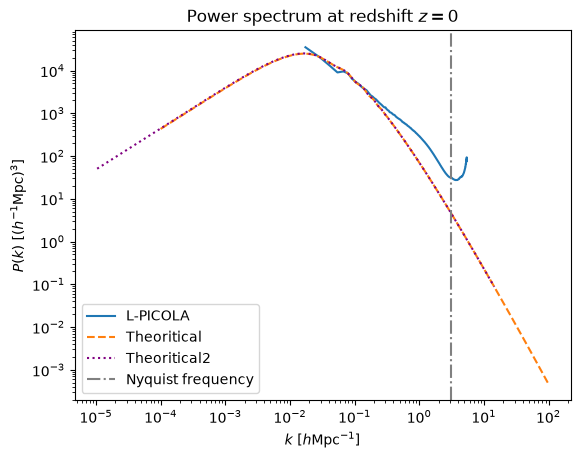

In [98]:
import matplotlib.pyplot as plt
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k~[h{\rm Mpc}^{-1}]$')
plt.ylabel(r'$P(k)~[(h^{-1}{\rm Mpc})^3]$')
plt.plot(k, Pk0, label='L-PICOLA')
plt.plot(k_theo, pk_theo, label='Theoritical', linestyle='--')
plt.plot(k_theo2, pk_theo2, label='Theoritical2', linestyle=':', color='purple')
plt.axvline(x=np.pi*BoxSize/grid, color='gray', linestyle='-.', label='Nyquist frequency')
#plt.xlim(min(k), max((k)))
#plt.ylim(min(Pk0)-2.5e1, max((Pk0)))
plt.title('Power spectrum at redshift $z=0$')
plt.legend()
plt.show()

### **Exercise2 (Optional): Repeit for different redshifts**

# Halo Mass Function

In [99]:
import numpy as np
import matplotlib.pyplot as plt

# Read halo catalogues
halos_z0 = np.load('halos/fof_z0.npz')
halos_z05 = np.load('halos/fof_z0p5.npz')

# Halo masses
mass_z0 = halos_z0['Mass']
mass_z05 = halos_z05['Mass']

# Simulation volume
BoxSize = halos_z0['BoxSize']
V = BoxSize**3

# Common logarithmic mass bins
Mmin = min(mass_z0.min(), mass_z05.min())
Mmax = max(mass_z0.max(), mass_z05.max())

bins = np.logspace(np.log10(Mmin), np.log10(Mmax), 15)

# Number of halos per bin
N_z0, _ = np.histogram(mass_z0, bins=bins)
N_z05, _ = np.histogram(mass_z05, bins=bins)

# Center of each mass bin
M = np.sqrt(bins[:-1]*bins[1:])

# Width of each logarithmic bin
dlnM = np.log(bins[1:]/bins[:-1])

# Halo Mass Function: dn/dlnM
HMF_z0 = N_z0/(V*dlnM)
HMF_z05 = N_z05/(V*dlnM)

# Plot only bins containing halos
mask_z0 = N_z0 > 0
mask_z05 = N_z05 > 0

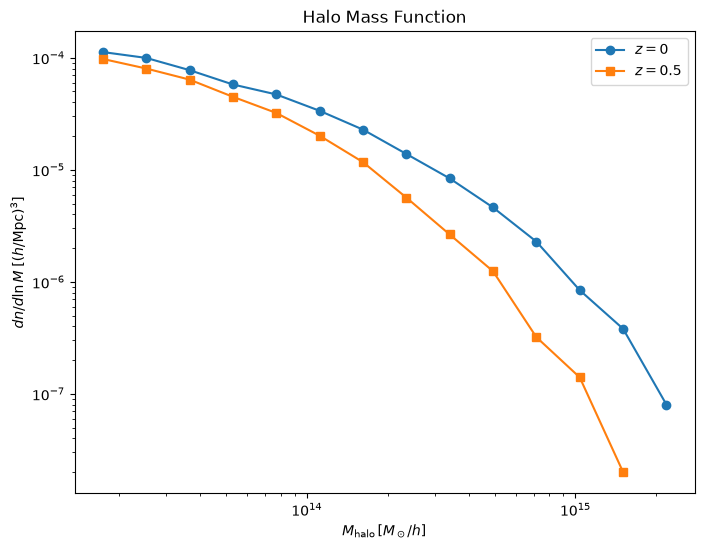

In [100]:
plt.figure(figsize=(8,6))

plt.loglog(M[mask_z0], HMF_z0[mask_z0], 'o-', label='$z=0$')
plt.loglog(M[mask_z05], HMF_z05[mask_z05], 's-', label='$z=0.5$')

plt.xlabel(r'$M_{\rm halo}\,[M_\odot/h]$')
plt.ylabel(r'$dn/d\ln M\;[(h/{\rm Mpc})^3]$')
plt.title('Halo Mass Function')

plt.legend()
plt.show()

Empirical fits of the HMF

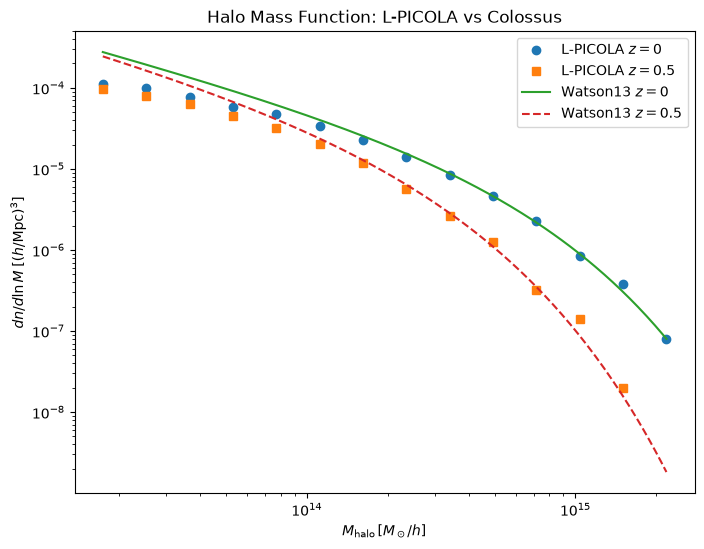

In [101]:
from colossus.cosmology import cosmology
from colossus.lss import mass_function

# Cosmology used in L-PICOLA
params = {'flat': True,
          'H0': 69.0,
          'Om0': 0.31,
          'Ob0': 0.048,
          'sigma8': 0.83,
          'ns': 0.96}

cosmology.setCosmology('myCosmo', **params)

# Mass range for the theoretical curve
M_theory = np.logspace(np.log10(M.min()), np.log10(M.max()), 200)

# Theoretical FoF Halo Mass Function
HMF_theory_z0 = mass_function.massFunction(M_theory, 0.0, mdef='fof', model='watson13', q_out='dndlnM')
HMF_theory_z05 = mass_function.massFunction(M_theory, 0.5, mdef='fof', model='watson13', q_out='dndlnM')

# Plot simulation + theory
plt.figure(figsize=(8,6))

plt.loglog(M[mask_z0], HMF_z0[mask_z0], 'o', label='L-PICOLA $z=0$')
plt.loglog(M[mask_z05], HMF_z05[mask_z05], 's', label='L-PICOLA $z=0.5$')

plt.loglog(M_theory, HMF_theory_z0, '-', label='Watson13 $z=0$')
plt.loglog(M_theory, HMF_theory_z05, '--', label='Watson13 $z=0.5$')

plt.xlabel(r'$M_{\rm halo}\,[M_\odot/h]$')
plt.ylabel(r'$dn/d\ln M\;[(h/{\rm Mpc})^3]$')
plt.title('Halo Mass Function: L-PICOLA vs Colossus')

plt.legend()
plt.show()

**Repetir cálculos para z=0 con número de pasos=5 y 20 y responder:**

**1. ¿Qué escalas de $P(k)$ son más sensibles al número de pasos de tiempo?\
2. ¿Por qué las escalas grandes convergen antes que las escalas pequeñas?\
3. ¿Cómo cambia la HMF cuando se reduce el número de pasos?**